<a href="https://colab.research.google.com/github/Bercine/Deep-learning-with-python-Francois-Chollet/blob/main/chap3_Introduction_to_Keras_and_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Listing 3.1 All-ones or all-zeros tensors


In [ ]:
import tensorflow as tf

In [ ]:
x = tf.ones(shape=(2, 1))
print(x)

tf.Tensor(
[[1.]
 [1.]], shape=(2, 1), dtype=float32)


In [ ]:
x = tf.zeros(shape=(2, 1))

In [ ]:
print(x)

tf.Tensor(
[[0.]
 [0.]], shape=(2, 1), dtype=float32)


#Listing 3.2 Random tensors


In [ ]:
x = tf.random.normal(shape=(3, 1), mean=0., stddev=1.)
print(x)

tf.Tensor(
[[-0.54716647]
 [ 0.70827496]
 [ 0.03018141]], shape=(3, 1), dtype=float32)


In [ ]:
x = tf.random.uniform(shape=(3, 1), minval=0., maxval=1.)
print(x)

tf.Tensor(
[[0.99027896]
 [0.34601188]
 [0.38473344]], shape=(3, 1), dtype=float32)


#Listing 3.4 TensorFlow tensors are not assignable


In [ ]:
"""x = tf.ones(shape=(2, 2))
x[0, 0] = 0."""

'x = tf.ones(shape=(2, 2))\nx[0, 0] = 0.'

#Listing 3.5 Creating a TensorFlow variable


In [ ]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[ 1.6302465 ],
       [ 0.48267022],
       [-0.45974073]], dtype=float32)>


#Listing 3.6 Assigning a value to a TensorFlow variable





In [ ]:
v.assign(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

In [ ]:
v[0, 0].assign(3.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

In [ ]:
v.assign(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

#Listing 3.9 A few basic math operations


In [ ]:
a = tf.ones((2, 2))
b = tf.square(a)
c = tf.sqrt(a)
d = b + c
e = tf.matmul(a, b)
e *= d

#Listing 3.10 Using the GradientTape


In [ ]:
input_var = tf.Variable(initial_value=3.)
with tf.GradientTape() as tape:
  result = tf.square(input_var)
gradient = tape.gradient(result, input_var)


#Listing 3.11 Using GradientTape with constant tensor inputs


In [ ]:
input_const = tf.constant(3.)
with tf.GradientTape() as tape:
   tape.watch(input_const)
   result = tf.square(input_const)
gradient = tape.gradient(result, input_const)

#Listing 3.12 Using nested gradient tapes to compute second-order gradients


In [ ]:
time = tf.Variable(0.)
with tf.GradientTape() as outer_tape:
  with tf.GradientTape() as inner_tape:
    position =  4.9 * time ** 2
  speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed, time)

#Listing 3.13 Generating two classes of random points in a 2D plane



In [ ]:
import numpy as np

In [ ]:
num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3],
    cov=[[1, 0.5], [0.5, 1]],
    size=num_samples_per_class
)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0],
    cov=[[1, 0.5], [0.5, 1]],
    size=num_samples_per_class
)

#Listing 3.14 Stacking the two classes into an array with shape (2000, 2)


In [ ]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

#Listing 3.15 Generating the corresponding targets (0 and 1)


In [ ]:
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))

#Listing 3.16 Plotting the two point classes (see figure 3.6)


In [ ]:
import matplotlib.pyplot as plt

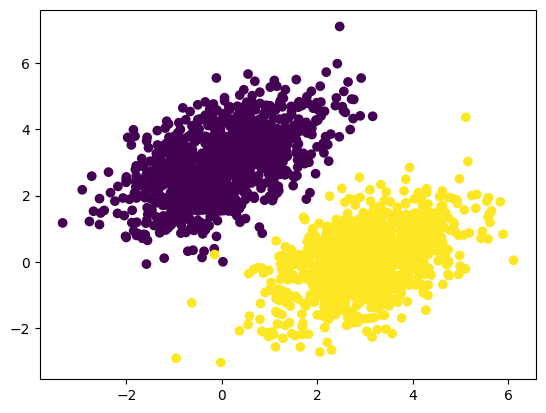

In [ ]:
plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

#Listing 3.17 Creating the linear classifier variables


In [ ]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

#Listing 3.18 The forward pass function


In [ ]:
def model(inputs):
  return tf.matmul(inputs, W) + b

#Listing 3.19 The mean squared error loss function


In [ ]:
def square_loss(targets, predictions):
  per_sample_losses = tf.square(targets - predictions)
  return tf.reduce_mean(per_sample_losses)

#Listing 3.20 The training step function



In [ ]:
learning_rate = 0.1

In [ ]:
def training_step(inputs, targets):
  with tf.GradientTape() as tape:
    predictions = model(inputs)
    loss = square_loss(predictions, targets)
  grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
  W.assign_sub(grad_loss_wrt_W * learning_rate)
  b.assign_sub(grad_loss_wrt_b * learning_rate)
  return loss

#Listing 3.21 The batch training loop


In [ ]:
for step in range(40):
  loss = training_step(inputs, targets)
  print(f"Loss at step {step} : {loss:.4f}")

Loss at step 0 : 1.9567
Loss at step 1 : 0.1485
Loss at step 2 : 0.1026
Loss at step 3 : 0.0911
Loss at step 4 : 0.0846
Loss at step 5 : 0.0792
Loss at step 6 : 0.0744
Loss at step 7 : 0.0700
Loss at step 8 : 0.0660
Loss at step 9 : 0.0623
Loss at step 10 : 0.0590
Loss at step 11 : 0.0560
Loss at step 12 : 0.0532
Loss at step 13 : 0.0507
Loss at step 14 : 0.0484
Loss at step 15 : 0.0463
Loss at step 16 : 0.0444
Loss at step 17 : 0.0427
Loss at step 18 : 0.0411
Loss at step 19 : 0.0396
Loss at step 20 : 0.0383
Loss at step 21 : 0.0371
Loss at step 22 : 0.0360
Loss at step 23 : 0.0350
Loss at step 24 : 0.0341
Loss at step 25 : 0.0333
Loss at step 26 : 0.0326
Loss at step 27 : 0.0319
Loss at step 28 : 0.0313
Loss at step 29 : 0.0307
Loss at step 30 : 0.0302
Loss at step 31 : 0.0297
Loss at step 32 : 0.0293
Loss at step 33 : 0.0289
Loss at step 34 : 0.0285
Loss at step 35 : 0.0282
Loss at step 36 : 0.0279
Loss at step 37 : 0.0276
Loss at step 38 : 0.0274
Loss at step 39 : 0.0272


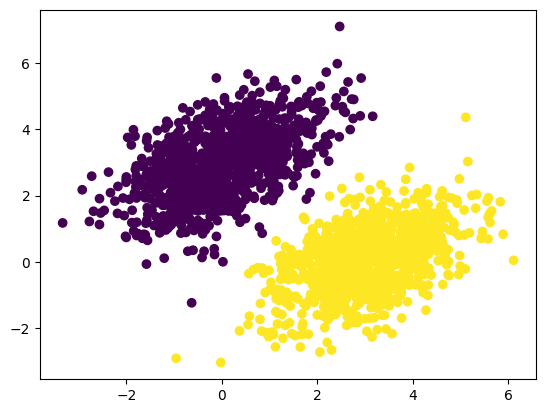

In [ ]:
predictions = model(inputs)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

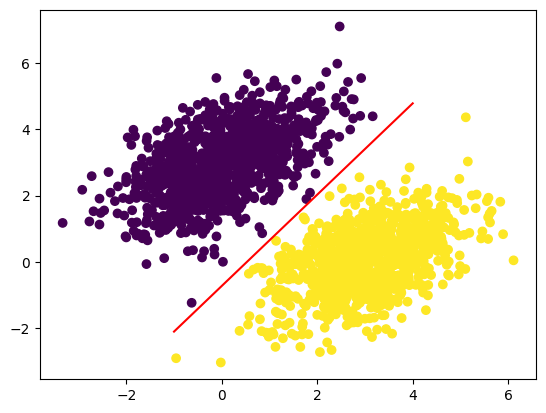

In [ ]:
x = np.linspace(-1, 4, 100)
y = - W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

#Listing 3.22 A Dense layer implemented as a Layer subclass


In [ ]:
from tensorflow import keras
class SimpleDense(keras.layers.Layer):
  def __init__(self, units, activation=None):
    super().__init__()
    self.units = units
    self.activation = activation

  def build(self, input_shape):
    input_dim = input_shape[-1]
    self.W = self.add_weight(shape=(input_dim, self.units),
                             initializer="random_normal")
    self.b = self.add_weight(shape=(self.units,),
                             initializer="zeros")

  def call(self, inputs):
    y = tf.matmul(inputs, self.W) + self.b
    if self.activation is not None:
      y = self.activation(y)
    return y

In [ ]:
my_dense = SimpleDense(units=32, activation=tf.nn.relu)
input_tensor = tf.ones(shape=(2, 784))
output_tensor = my_dense(input_tensor)
print(output_tensor.shape)

(2, 32)


In [ ]:
from tensorflow.keras import layers
layer = layers.Dense(32, activation="relu")

In [ ]:
from tensorflow.keras import models
model = models.Sequential([
    layers.Dense(32, activation="relu"),
    layers.Dense(32)
])

In [ ]:
model = keras.Sequential([
    SimpleDense(32, activation=tf.nn.relu),
    SimpleDense(64, activation=tf.nn.relu),
    SimpleDense(32, activation=tf.nn.relu),
    SimpleDense(10, activation=tf.nn.softmax)
])

#Listing 3.23 Calling fit() with NumPy data


In [ ]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(optimizer="rmsprop",
      loss="mean_squared_error",
      metrics=["accuracy"])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    inputs,
    targets,
    epochs=5,
    batch_size=128
)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5600 - loss: 2.8602
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5685 - loss: 2.6024 
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5750 - loss: 2.3898 
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5830 - loss: 2.1912 
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5965 - loss: 2.0036 


In [ ]:
history.history

{'accuracy': [0.5600000023841858,
  0.5684999823570251,
  0.574999988079071,
  0.5830000042915344,
  0.5964999794960022],
 'loss': [2.8602347373962402,
  2.6023833751678467,
  2.389772891998291,
  2.191150426864624,
  2.003647565841675]}

#Listing 3.24 Using the validation_data argument


In [ ]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()]
)

In [ ]:
indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]

In [ ]:
num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]

In [ ]:
model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, val_targets)
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accuracy: 0.9229 - loss: 0.3286 - val_binary_accuracy: 0.9133 - val_loss: 0.1273
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.9571 - loss: 0.0739 - val_binary_accuracy: 0.6983 - val_loss: 0.2636
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.9643 - loss: 0.0707 - val_binary_accuracy: 1.0000 - val_loss: 0.0334
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.9486 - loss: 0.0766 - val_binary_accuracy: 0.9983 - val_loss: 0.0257
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.9550 - loss: 0.0683 - val_binary_accuracy: 0.6600 - val_loss: 0.3528


In [ ]:
predictions = model.predict(val_inputs, batch_size=128)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [ ]:
predictions[:10]

array([[1.3107462 ],
       [1.6072171 ],
       [1.3029958 ],
       [1.7216218 ],
       [0.4454872 ],
       [1.8207862 ],
       [0.20194006],
       [1.0928098 ],
       [0.3901233 ],
       [1.4440613 ]], dtype=float32)